In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv('/kaggle/input/imdb-sentiment-analysis/IMDB Dataset.csv')

In [2]:
#Print first few entries in the data
print("First few rows of the dataset: ")
print(data.head())

First few rows of the dataset: 
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
#Printing the last few entries in the data
print("The last few entries of the dataset are: ")
data.tail()

The last few entries of the dataset are: 


,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [4]:
#Printing the summary statistics
print("nSummary statistics: ")
print(data.describe())

nSummary statistics: 
                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                                    5     25000


In [5]:
#Print the information about the dataset
print("\nInformation about the dataset: ")
print(data.info())


Information about the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [6]:
print(data.shape)

(50000, 2)


In [7]:
print(data.columns)

Index(['review', 'sentiment'], dtype='object')


In [8]:
#Print the null values from all the columns
print(data.isnull().sum())

review       0
sentiment    0
dtype: int64


In [9]:
#Sentiment Count
data['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer
from nltk.tokenize import word_tokenize  
from sklearn.model_selection import train_test_split

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
stemmer = LancasterStemmer()

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabetical characters
    text = text.lower()  # Convert text to lowercase
    tokens = word_tokenize(text)  # Tokenize text
    stop_words = set(stopwords.words("english"))  # Get stopwords
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    tokens = [stemmer.stem(word) for word in tokens]  # Apply stemming
    return " ".join(tokens)
# Apply preprocessing function to the review column
data['cleaned_review'] = data['review'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [11]:
print(data.head())

                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

                                      cleaned_review  
0  on review ment watch oz episod youl hook right...  
1  wond littl produc film techn unassum oldtimebb...  
2  thought wond way spend tim hot sum weekend sit...  
3  bas ther famy littl boy jak think ther zomby c...  
4  pet mat lov tim money vis stun film watch mr m...  


In [12]:
from sklearn.model_selection import train_test_split
#Feature engineering
X = data['cleaned_review']  # Features
y = data['sentiment']  # Target labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
# Check the shape of the split data
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 37500
Testing set size: 12500


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

# Fit and transform the training data
X_train_vect = vectorizer.fit_transform(X_train)
# Transform the testing data 
X_test_vect = vectorizer.transform(X_test)

# Check the shape of the vectorized data
print(f"Shape of X_train_vect: {X_train_vect.shape}")
print(f"Shape of X_test_vect: {X_test_vect.shape}")

Shape of X_train_vect: (37500, 126961)
Shape of X_test_vect: (12500, 126961)


In [14]:
#Encoding the target variable
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)  
y_test_enc = label_encoder.transform(y_test)   

In [15]:
#Logistic regression
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_vect, y_train_enc)
y_pred_log_reg = log_reg.predict(X_test_vect)

In [16]:
#Performance metrics for Logistic Regression
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(y_test_enc, y_pred_log_reg)
report = classification_report(y_test_enc, y_pred_log_reg)

# Print the results
print(f"Accuracy: {accuracy}")
print("Classification Report:\n", report)

Accuracy: 0.88616
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      6157
           1       0.88      0.90      0.89      6343

    accuracy                           0.89     12500
   macro avg       0.89      0.89      0.89     12500
weighted avg       0.89      0.89      0.89     12500



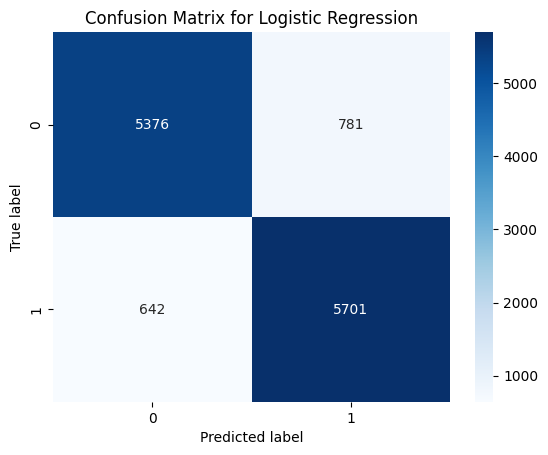

In [17]:
#Confusion matrix for Logistic Regression 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test_enc, y_pred_log_reg)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [18]:
#Support Vector Machine Classifier
from sklearn.svm import SVC
svm = SVC(kernel='sigmoid',C=1.0,gamma='scale') 
svm.fit(X_train_vect,y_train_enc)
y_pred_svm = svm.predict(X_test_vect)

In [19]:
#Performance metrics for Support Vector Machine Classifier
from sklearn.metrics import classification_report, accuracy_score

accuracy_svm = accuracy_score(y_test_enc, y_pred_svm)
report_svm = classification_report(y_test_enc, y_pred_svm)

# Print the results
print(f"Accuracy: {accuracy_svm}")
print("Classification Report:\n", report_svm)

Accuracy: 0.89016
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89      6157
           1       0.88      0.90      0.89      6343

    accuracy                           0.89     12500
   macro avg       0.89      0.89      0.89     12500
weighted avg       0.89      0.89      0.89     12500



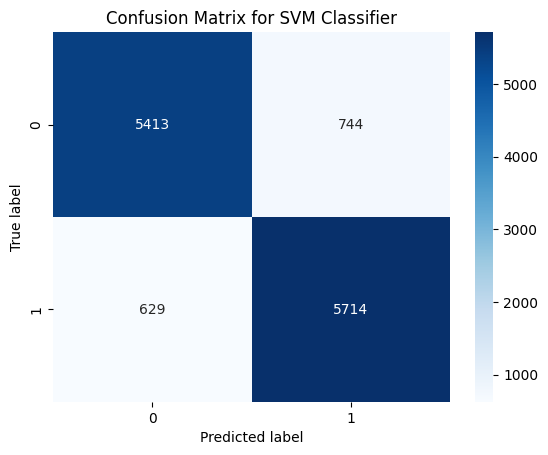

In [20]:
#Confusion matrix for SVM Classifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_svm = confusion_matrix(y_test_enc, y_pred_svm)
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for SVM Classifier')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [21]:
#Decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_vect, y_train_enc)
y_pred_dt = dt.predict(X_test_vect)

In [22]:
#Performance metrics for Decision Tree Classifier
from sklearn.metrics import classification_report, accuracy_score

accuracy_dt = accuracy_score(y_test_enc, y_pred_dt)
report_dt = classification_report(y_test_enc, y_pred_dt)

# Print the results
print(f"Accuracy: {accuracy_dt}")
print("Classification Report:\n", report_dt)

Accuracy: 0.71456
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.72      0.71      6157
           1       0.72      0.71      0.72      6343

    accuracy                           0.71     12500
   macro avg       0.71      0.71      0.71     12500
weighted avg       0.71      0.71      0.71     12500



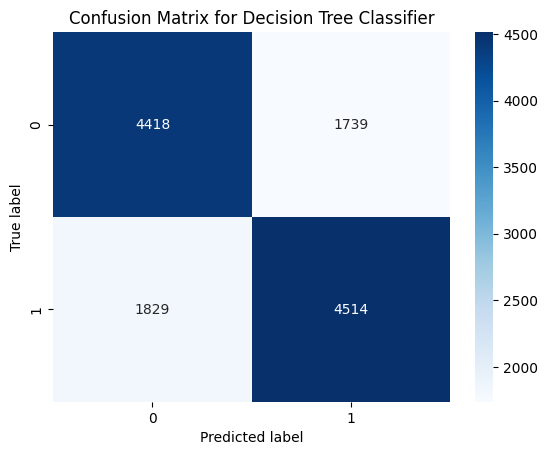

In [23]:
#Confusion matrix for Decision Tree Classifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_dt = confusion_matrix(y_test_enc, y_pred_dt)
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [24]:
#RandomForest classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train_vect, y_train_enc)
y_pred_rf = rf.predict(X_test_vect)

In [26]:
#Performance metrics for RandomForest Classifier
from sklearn.metrics import classification_report, accuracy_score

accuracy_rf = accuracy_score(y_test_enc, y_pred_rf)
report_rf = classification_report(y_test_enc, y_pred_rf)

# Print the results
print(f"Accuracy: {accuracy_rf}")
print("Classification Report:\n",report_rf)

Accuracy: 0.84504
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84      6157
           1       0.85      0.84      0.85      6343

    accuracy                           0.85     12500
   macro avg       0.85      0.85      0.85     12500
weighted avg       0.85      0.85      0.85     12500



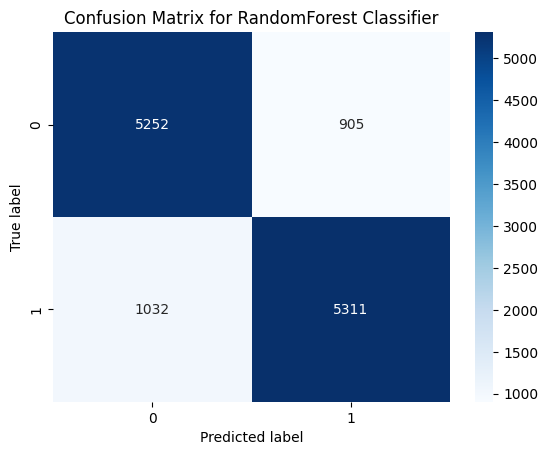

In [27]:
#Confusion matrix for RandomForest Classifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_rf = confusion_matrix(y_test_enc, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for RandomForest Classifier')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [28]:
#NaiveBayes Classifier(Multinomial NaiveBayes)
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_vect, y_train_enc)
y_pred_nb = nb.predict(X_test_vect)

In [29]:
#Performance metrics of NaiveBayes Classifier
from sklearn.metrics import classification_report, accuracy_score

accuracy_nb = accuracy_score(y_test_enc, y_pred_nb)
report_nb = classification_report(y_test_enc, y_pred_nb)

# Print the results
print(f"Accuracy: {accuracy_nb}")
print("Classification Report:\n", report_nb)

Accuracy: 0.85736
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      6157
           1       0.88      0.84      0.86      6343

    accuracy                           0.86     12500
   macro avg       0.86      0.86      0.86     12500
weighted avg       0.86      0.86      0.86     12500



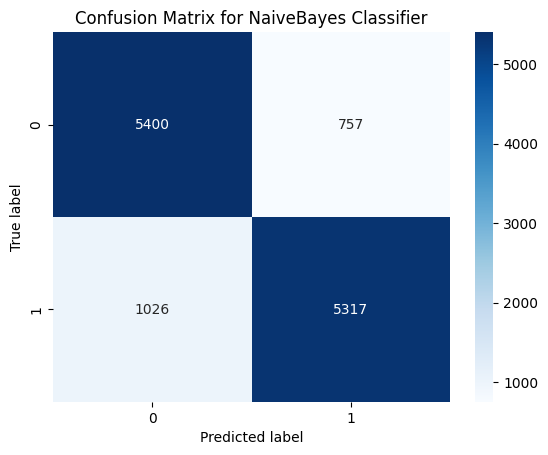

In [30]:
#Confusion matrix for NaiveBayes Classifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_nb = confusion_matrix(y_test_enc, y_pred_nb)
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for NaiveBayes Classifier')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [31]:
#GradientBoosting Machine
from sklearn.ensemble import GradientBoostingClassifier
gbm = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbm.fit(X_train_vect, y_train_enc)
y_pred_gbm = gbm.predict(X_test_vect)

In [32]:
#Performance metrics for GradientBoosting Machine
from sklearn.metrics import classification_report,accuracy_score

accuracy_gbm = accuracy_score(y_test_enc, y_pred_gbm)
report_gbm = classification_report(y_test_enc, y_pred_gbm)

# Print the results
print(f"Accuracy: {accuracy_gbm}")
print("Classification Report:\n",report_gbm)

Accuracy: 0.80968
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.77      0.80      6157
           1       0.79      0.85      0.82      6343

    accuracy                           0.81     12500
   macro avg       0.81      0.81      0.81     12500
weighted avg       0.81      0.81      0.81     12500



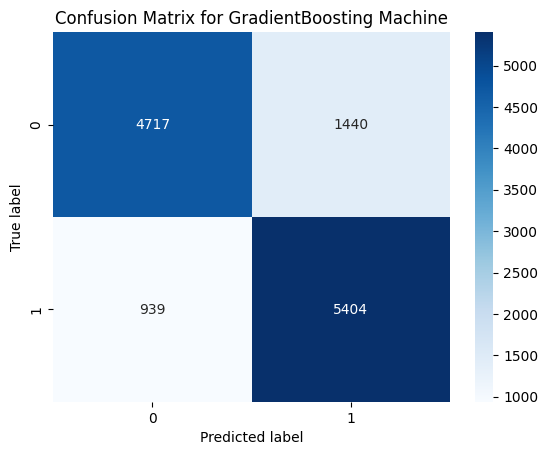

In [33]:
#Confusion matrxi for GradientBoosting Machine
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_gbm = confusion_matrix(y_test_enc, y_pred_gbm)
sns.heatmap(conf_matrix_gbm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for GradientBoosting Machine')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [34]:
#LightGBM Classifier
import lightgbm as lgb
lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42)
lgbm.fit(X_train_vect,y_train_enc)
y_pred_lgbm = lgbm.predict(X_test_vect)

[LightGBM] [Info] Number of positive: 18657, number of negative: 18843
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.208814 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 563825
[LightGBM] [Info] Number of data points in the train set: 37500, number of used features: 9312
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497520 -> initscore=-0.009920
[LightGBM] [Info] Start training from score -0.009920


In [35]:
#Perfromace metrics for LightGBM Classifier
from sklearn.metrics import classification_report, accuracy_score

accuracy_lgbm = accuracy_score(y_test_enc, y_pred_lgbm)
report_lgbm = classification_report(y_test_enc, y_pred_lgbm)

# Print the results
print(f"Accuracy: {accuracy_lgbm}")
print("Classification Report:\n",report_lgbm)

Accuracy: 0.85232
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85      6157
           1       0.85      0.86      0.86      6343

    accuracy                           0.85     12500
   macro avg       0.85      0.85      0.85     12500
weighted avg       0.85      0.85      0.85     12500



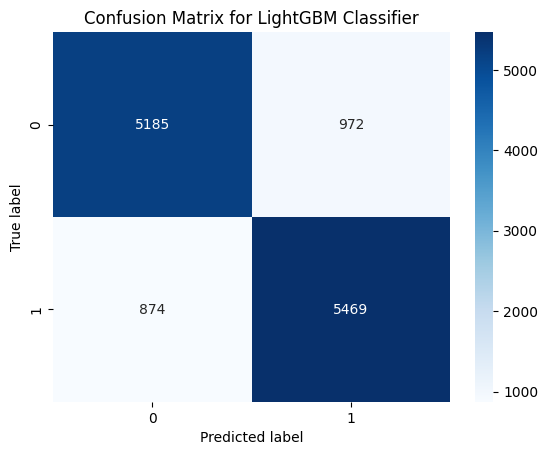

In [36]:
#Confusion matrix for LightGBM Classifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_lgbm = confusion_matrix(y_test_enc, y_pred_lgbm)
sns.heatmap(conf_matrix_lgbm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for LightGBM Classifier')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [37]:
#CatBoostClassifier
import catboost
catb = catboost.CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=0)
catb.fit(X_train_vect, y_train_enc)
y_pred_catb = catb.predict(X_test_vect)

In [38]:
#Performance metrics for CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

accuracy_catb = accuracy_score(y_test_enc, y_pred_catb)
report_catb = classification_report(y_test_enc, y_pred_catb)

# Print the results
print(f"Accuracy: {accuracy_catb}")
print("Classification Report:\n",report_catb)

Accuracy: 0.83272
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.80      0.82      6157
           1       0.81      0.87      0.84      6343

    accuracy                           0.83     12500
   macro avg       0.83      0.83      0.83     12500
weighted avg       0.83      0.83      0.83     12500



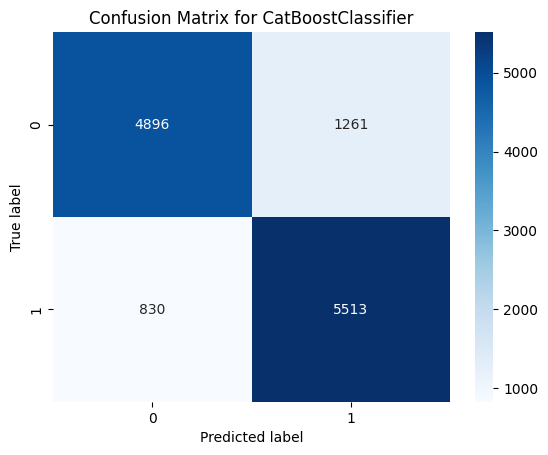

In [39]:
#Confusion matrix for CatBoostClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_catb = confusion_matrix(y_test_enc, y_pred_catb)
sns.heatmap(conf_matrix_catb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for CatBoostClassifier')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [40]:
#XGBoost Classifier
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100,random_state=42)
xgb.fit(X_train_vect, y_train_enc)
y_pred_xgb = xgb.predict(X_test_vect)

In [41]:
#Performance metrics for XGBoost Classifier
from sklearn.metrics import classification_report, accuracy_score

accuracy_xgb = accuracy_score(y_test_enc, y_pred_xgb)
report_xgb = classification_report(y_test_enc, y_pred_xgb)

# Print the results
print(f"Accuracy: {accuracy_xgb}")
print("Classification Report:\n",report_xgb)

Accuracy: 0.85064
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.85      6157
           1       0.84      0.87      0.85      6343

    accuracy                           0.85     12500
   macro avg       0.85      0.85      0.85     12500
weighted avg       0.85      0.85      0.85     12500



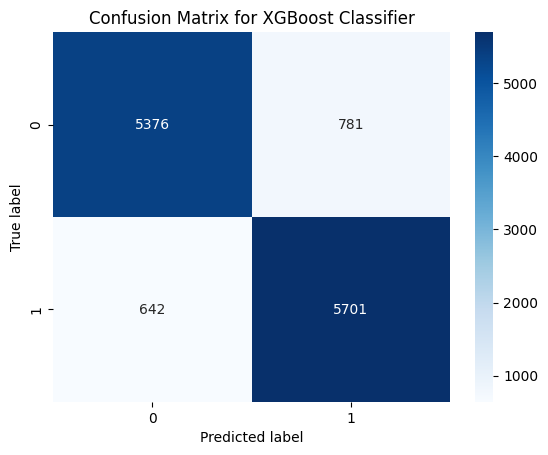

In [42]:
#Confusion matrxi for XGBoost Classifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_xgb = confusion_matrix(y_test_enc, y_pred_xgb)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for XGBoost Classifier')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()